# 📈 Time-Series Data Preparation & Forecasting Setup

In this phase, we will pivot our perspective from **Customer Segmentation** to **Revenue Forecasting**. We will:
1. Prepare our transaction data into a structured Time-Series format.
2. Resample the data (e.g., Daily/Weekly revenue).
3. Perform **Time-Series Decomposition** to extract Trends and Seasonality.
4. Run **Stationarity Tests** (Augmented Dickey-Fuller Test) to evaluate if the data is ready for ARIMA/Prophet modeling.

In [ ]:
# Loading Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels for time-series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Data Preparation for Time Series
Time Series requires a continuous, evenly-spaced index of DateTime objects. We will load our cleaned transaction data and calculate total revenue grouped by Date.

In [40]:
# We only need InvoiceDate and TotalPrice for this analysis
df = pd.read_csv('../data/processed/online_retail_initial.csv', usecols=['InvoiceDate', 'TotalPrice'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Strip out the time)
df['Date'] = df['InvoiceDate'].dt.date
df['Date'] = pd.to_datetime(df['Date'])

# Get Daily Revenue
daily_revenue = df.groupby('Date')['TotalPrice'].sum().reset_index()
daily_revenue.set_index('Date', inplace=True)

- Time-series models strictly require continuous daily data.
- So, if there are days with no sales (e.g., holidays), they might be missing. We need to fill them with 0.

In [41]:
daily_revenue

,TotalPrice
Date,
2009-12-01,53010.76
2009-12-02,62583.66
2009-12-03,68027.59
2009-12-04,40195.80
2009-12-05,9803.05
...,...
2011-12-05,57630.20
2011-12-06,54109.39
2011-12-07,74952.61


In [42]:
daily_revenue = daily_revenue.asfreq('D', fill_value=0)

print(f"Time Series range: {daily_revenue.index.min().date()} to {daily_revenue.index.max().date()}")
display(daily_revenue.head())

Time Series range: 2009-12-01 to 2011-12-09


,TotalPrice
Date,
2009-12-01,53010.76
2009-12-02,62583.66
2009-12-03,68027.59
2009-12-04,40195.80
2009-12-05,9803.05


### Plotting the Daily Revenue

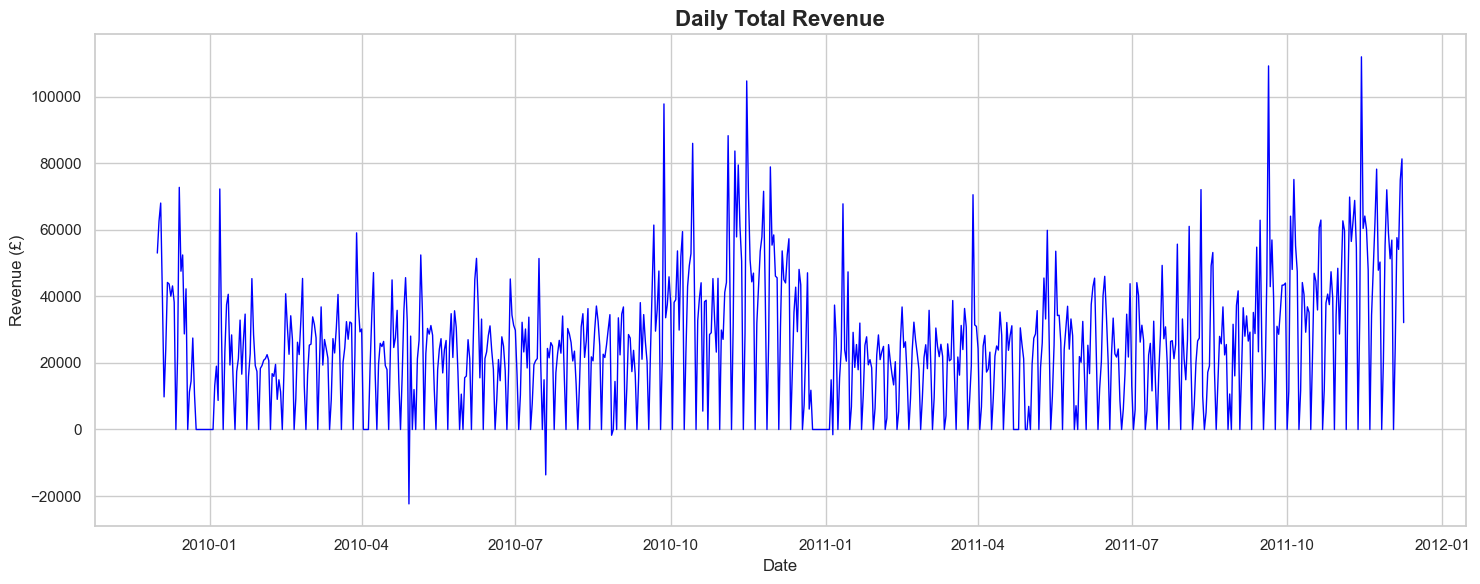

In [43]:
plt.figure(figsize=(15, 6))
plt.plot(daily_revenue.index, daily_revenue['TotalPrice'], color='blue', linewidth=1)
plt.title('Daily Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** Daily data is very noisy and heavily influenced by weekends or immediate retail shocks. To model long-term trends, we usually resample to **Weekly** or **Monthly** data.

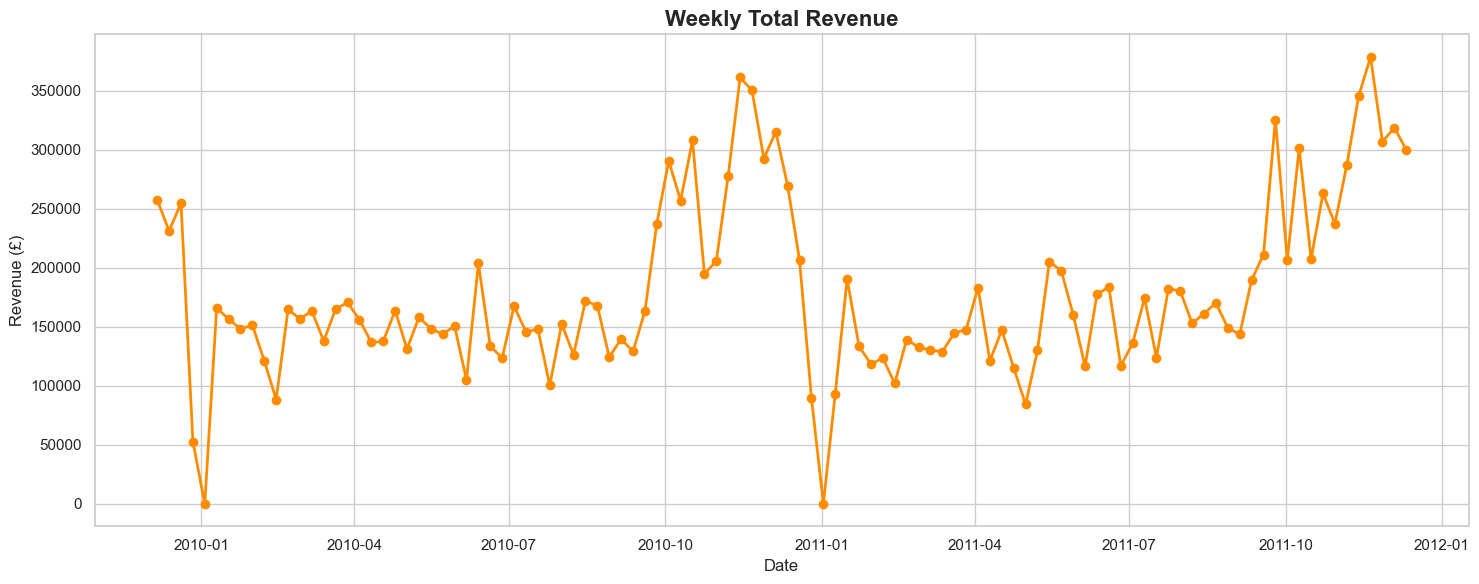

In [44]:
# Resample to Weekly Revenue (W)
weekly_revenue = daily_revenue.resample('W').sum()

plt.figure(figsize=(15, 6))
plt.plot(weekly_revenue.index, weekly_revenue['TotalPrice'], color='darkorange', linewidth=2, marker='o')
plt.title('Weekly Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.tight_layout()
plt.show()

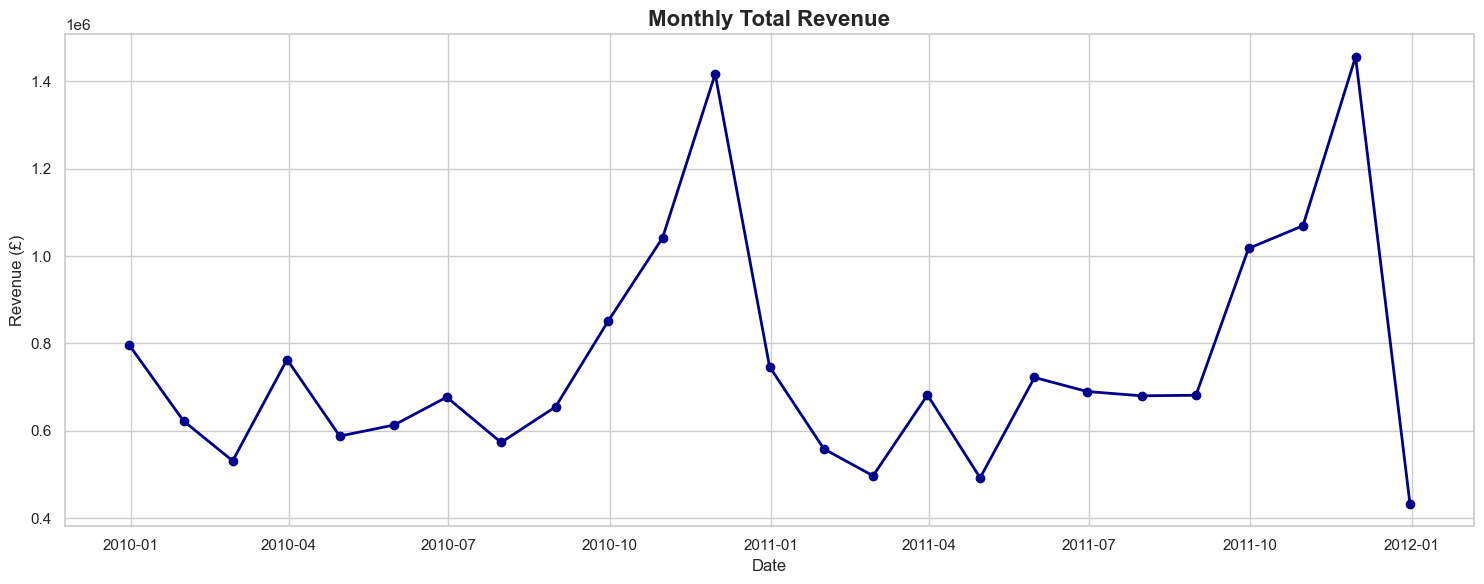

In [45]:
# Resample to Monthly Revenue (M)
monthly_revenue = daily_revenue.resample('M').sum()

plt.figure(figsize=(15, 6))
plt.plot(monthly_revenue.index, monthly_revenue['TotalPrice'], color='darkblue', linewidth=2, marker='o')
plt.title('Monthly Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Time-Series Decomposition
Forecasting models try to predict the future by separating historical data into three core components:
1. **Trend**: The overall long-term direction of the data (going up or down).
2. **Seasonality**: Repeating short-term cycles (e.g., higher sales every December).
3. **Residual (Noise)**: The random, unpredictable variance left over.

**Formula:**
```
Series = Trend + Seasonal + Residual
```

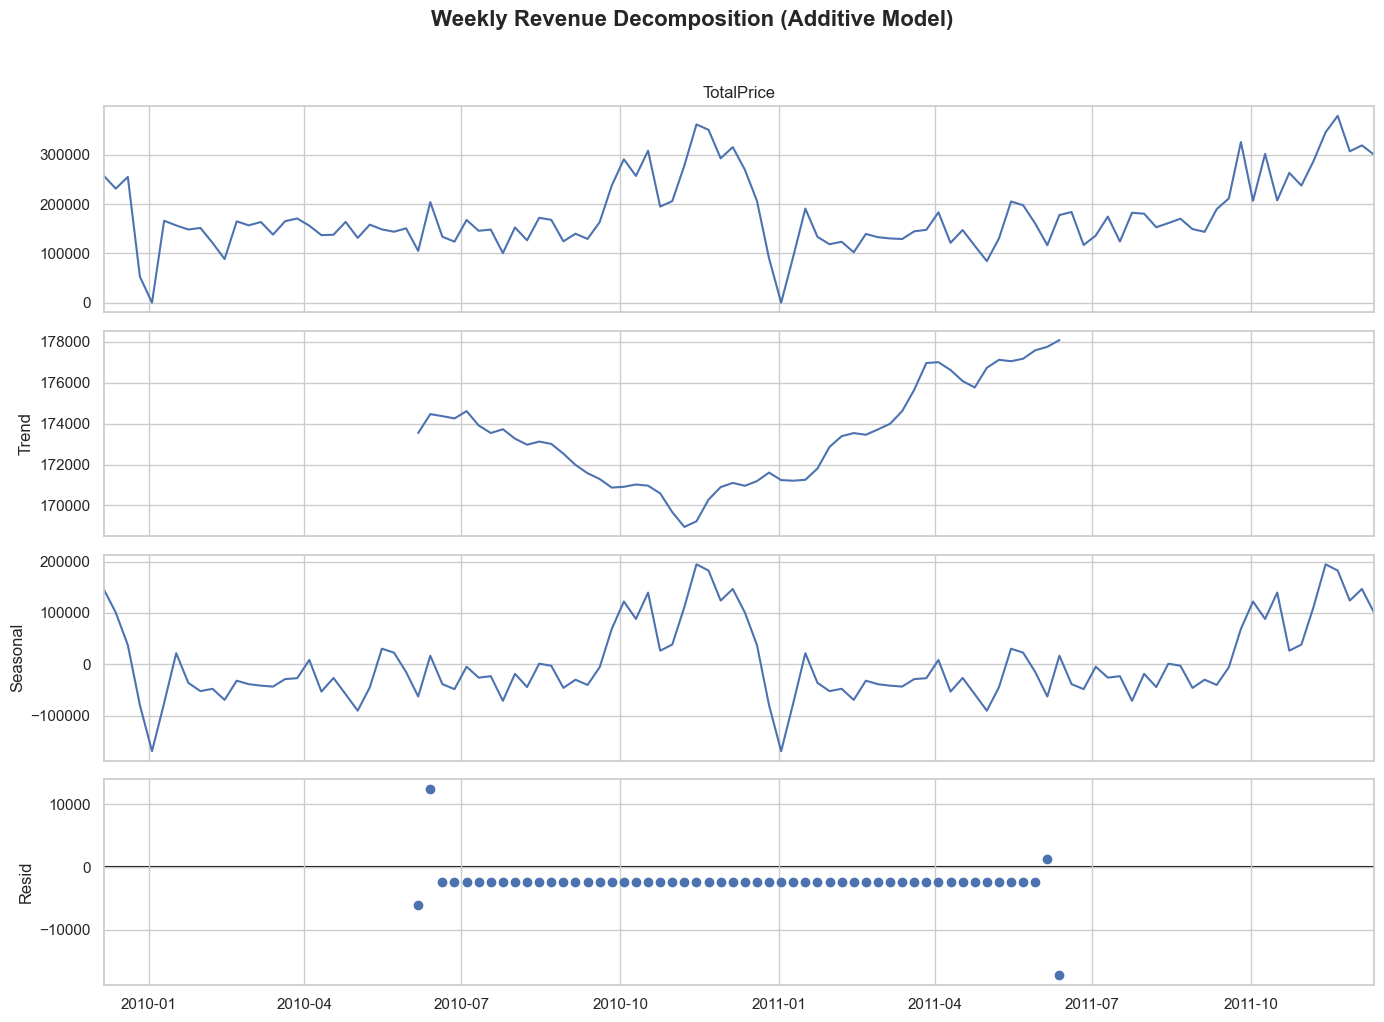

In [46]:
# We will decompose the Weekly Revenue to find the underlying trend and seasonality.
decomposition = seasonal_decompose(weekly_revenue['TotalPrice'], model='additive')

# Plot the decomposition
fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Weekly Revenue Decomposition (Additive Model)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Business Insights from Decomposition:**
- **Trend**: We can clearly see macroeconomic trends (e.g., dipping in mid-2010, rising heavily towards late 2010 and late 2011).
- **Seasonality**: The retail data exhibits strict cyclical patterns, indicating strong seasonal shopping behaviors.

## 3. Stationarity Test (Augmented Dickey-Fuller)
Most statistical forecasting models (like ARIMA) require the time series to be **Stationary**.

A stationary time series has a constant mean and variance over time (i.e., no extreme long-term trends).

| Hypothesis | Meaning |
|------------|---------|
| **H₀ (Null)** | Series is **non-stationary** (has a unit root) |
| **H₁ (Alternative)** | Series is **stationary** |

**Interpretation:**

| p-value | Result | Action |
|---------|--------|--------|
| **p < 0.05** | ✅ Reject H₀ → Series is **stationary** | What we need for modeling |
| **p ≥ 0.05** | ❌ Fail to reject H₀ → Series is **non-stationary** | Needs differencing |

In [47]:
def run_adf_test(timeseries, series_name):
    print(f"=== Augmented Dickey-Fuller Test: {series_name} ===")
    result = adfuller(timeseries, autolag='AIC')
    
    labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
    formats = ['.5f', '.5f', 'd', 'd'] 
    
    for value, label, fmt in zip(result, labels, formats):
        print(f"{label}: {value:{fmt}}")
        
    print("\nCritical Values:")
    for key, val in result[4].items():
        print(f"\t{key}: {val:.3f}")
        
    if result[1] <= 0.05:
        print("\n✅ Conclusion: p-value ≤ 0.05 → REJECT H₀ → Data is STATIONARY.")
    else:
        print("\n⚠️ Conclusion: p-value > 0.05 → FAIL TO REJECT H₀ → Data is NOT STATIONARY.")

run_adf_test(weekly_revenue['TotalPrice'], 'Weekly Total Revenue')

=== Augmented Dickey-Fuller Test: Weekly Total Revenue ===
ADF Test Statistic: -3.98332
p-value: 0.00150
# Lags Used: 0
Number of Observations Used: 105

Critical Values:
	1%: -3.494
	5%: -2.889
	10%: -2.582

✅ Conclusion: p-value ≤ 0.05 → REJECT H₀ → Data is STATIONARY.


### Making the Data Stationary (Differencing)
If the ADF test concluded that the data is NOT stationary (which is common for retail data with increasing growth trends), we must apply **Differencing**. Differencing means we subtract the previous week's sales from the current week's sales to stabilize the mean.

In [48]:
# First-Order Differencing
weekly_revenue_diff = weekly_revenue['TotalPrice'].diff().dropna()

# Re-run the ADF Test
run_adf_test(weekly_revenue_diff, 'Differenced Weekly Revenue')

=== Augmented Dickey-Fuller Test: Differenced Weekly Revenue ===
ADF Test Statistic: -8.53854
p-value: 0.00000
# Lags Used: 2
Number of Observations Used: 102

Critical Values:
	1%: -3.496
	5%: -2.890
	10%: -2.582

✅ Conclusion: p-value ≤ 0.05 → REJECT H₀ → Data is STATIONARY.


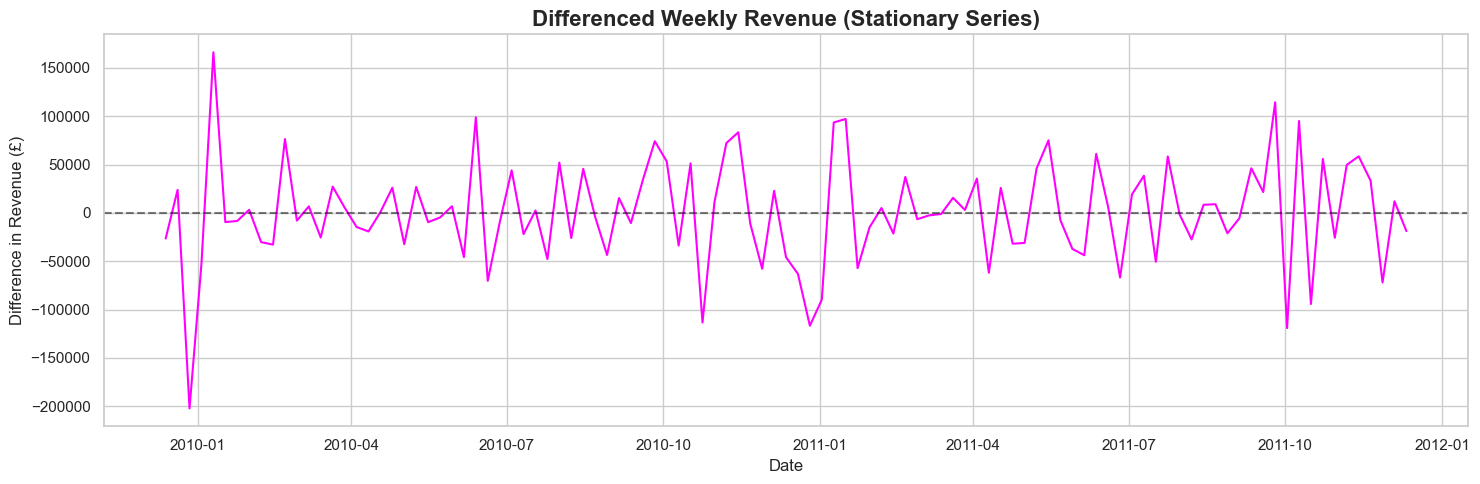

In [49]:
# Plot the differenced (stationary) time series
plt.figure(figsize=(15, 5))
plt.plot(weekly_revenue_diff.index, weekly_revenue_diff, color='magenta')
plt.axhline(0, linestyle='--', color='black', alpha=0.5)
plt.title('Differenced Weekly Revenue (Stationary Series)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Difference in Revenue (£)')
plt.tight_layout()
plt.show()

**The dataset is now perfectly formatted to be ingested by advanced forecasting models such as ARIMA, SARIMA, or Facebook Prophet in the next phase!**